# Charm-Decay — a quantitative teardown ⏳
### Daily SPY 1993–2026 · HAC t-stats · calendar-randomisation placebo · pre/post-2012 split

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Charm_rally%3F: Busted](https://img.shields.io/badge/Charm_rally%3F-Busted-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error.  We test whether the charm (delta-decay) dealer-flow story produces a measurable directional drift in SPY over the pre-OpEx window, and whether any window rule clears the inference bar.

> **Not investment advice.** Real data: Yahoo daily bars SPY 1993–2026, auto-adjusted (total-return proxy), as-of 2026-07-10; the offline core and tests run on a deterministic synthetic tape.  Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **💡 `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from charm_decay import data, strategy as st

TICKER, AS_OF = "SPY", "2026-07-10"
CACHE_PATH = data._cache_path(TICKER, data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def get_bars():
    b = data.fetch_daily(TICKER, start="1993-01-01", fetch=False)
    return b[b.index <= pd.Timestamp(AS_OF)]

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-07-10).
R = dict(
    ticker="SPY", n_days=8418, start="1993-01-29", end="2026-07-10", fp="a7ff45641491",
    n_opex_defined=408, n_pre_days=2005, n_post_days=2005,
    pre_mean=4.54, pre_base=4.85, pre_diff=-0.32, pre_t=-0.13, pre_n=2005,
    post_mean=3.48, post_base=5.18, post_diff=-1.70, post_t=-0.76, post_n=2005,
    asym_pre=4.54, asym_post=3.48, asym_diff=1.05, asym_t=0.31,
    q_all_diff=-0.32, q_all_t=-0.13, q_qtr_diff=-1.06, q_qtr_t=-0.23, q_qtr_n=670,
    pl_true_t=-0.13, pl_mean_abs=1.08, pl_max_abs=3.68, pl_n=52, pl_p=0.94,
    pl_planted_true_t=3.59, pl_planted_p=0.019,
    pre2012_diff=1.20, pre2012_t=0.35, pre2012_n=1135,
    post2012_diff=-2.25, post2012_t=-0.67, post2012_n=870,
    ov_n=1992, ov_mean=4.56, ov_sharpe=0.62, ov_cagr=10.25, ov_t=1.87,
    ls_n=3983, ls_mean=0.53, ls_sharpe=0.07, ls_cagr=-0.36, ls_t=0.31,
    bh_mean=4.78, bh_sharpe=0.65, bh_cagr=10.86,
)
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pre-OpEx drift -0.32 bps (HAC t = -0.13); rally-then-fade +1.05 bps (t = +0.31); nothing clears |t| = 2. |
| **Tradability** | `MIRAGE` | Long overlay Sharpe 0.62 = buy-and-hold 0.65; long/short 'rally-then-fade' CAGR -0.4%/yr (< cash). |
| **Charm rally?** | `BUSTED` | Calendar-randomisation places the real anchor at the 94th percentile of fake anchors (empirical p = 0.94). |

> 💡 The charm Greek is real and dealers hedge it — but the aggregate directional footprint on SPY is statistically indistinguishable from a randomly chosen week.

## 1 · The claim, steelmanned

Let $I_{t}$ indicate that trading day $t$ falls in the pre-OpEx charm window (the five sessions ending on the 3rd-Friday expiry) and $r_t$ the close-to-close return.  Charm is $\partial\Delta/\partial t$; a dealer short a book of near-the-money options sees its net delta bleed toward zero as $t\to$ expiry, and re-hedges directionally.  The hypotheses:

- **H₁ (pre-drift).** $\mathbb{E}[r_t\mid I_t=1] > \mathbb{E}[r_t\mid I_t=0]$ — the charm week drifts up.
- **H₂ (give-back).** $\mathbb{E}[r_t\mid \text{post}] < \mathbb{E}[r_t\mid \text{base}]$.
- **H₃ (asymmetry).** pre-mean − post-mean $> 0$ and significant.
- **H₄ (special anchor).** the pre-window drift *t* is extreme relative to arbitrary calendar anchors.
- **H₅ (tradable).** a charm-window rule clears the inference bar net of costs.

We reject H₁–H₅ on the SPY tape.

## 2 · So what? — what rides on each answer

A calendar-anchored directional effect needs no forecast and no signal computation — it is the cheapest possible alpha if it exists, and the easiest to arbitrage away if discovered.  H₄ is the crux: a real hedging-flow effect must be *anchored* to the real expiry, not to any week.  If shuffling the anchor leaves the *t*-distribution unchanged, the drift is a property of SPY's general return distribution, not of OpEx — and the charm mechanism, whatever its micro reality, leaves no macro fingerprint.

## 3 · How we'd know — the protocol

- **Data.** SPY daily OHLCV, Yahoo Finance auto-adjusted (total-return proxy), 1993-01-29 → 2026-07-10, n = 8,418 days.
- **Anchor.** 3rd Friday of every month, pure Gregorian calendar — no look-ahead.  Windows measured in **trading days** (holidays never smear them).
- **Windows.** Pre = 5 sessions ending on OpEx; post = 5 sessions after.
- **Return.** Close-to-close simple return; position calendar-set (no execution lag needed) but entered at the prior close so the first day's return is earned.
- **Inference.** Newey-West HAC *t* on the window-vs-baseline mean difference; five sub-tests → Bonferroni bar |t| ≥ 2.58 for family-wise α = 5%.
- **Placebo.** Slide the anchor by ±5…±30 trading days (52 fake anchors) → empirical *t*-null and two-sided p-value for the real anchor.
- **Restriction.** Quarterly triple-witching months only (largest books).
- **Structural break.** Pre/post-2012 (charm/vanna narrative + weekly/0DTE era).
- **Positive control.** Synthetic tape with a planted pre-window drift confirms the engine — and the placebo — isolate the effect when one exists.

## 4 · The teardown

### 4a · Drift and asymmetry — null on every window

Pre-OpEx, post-OpEx, and the pre-minus-post asymmetry, each with its HAC *t*.

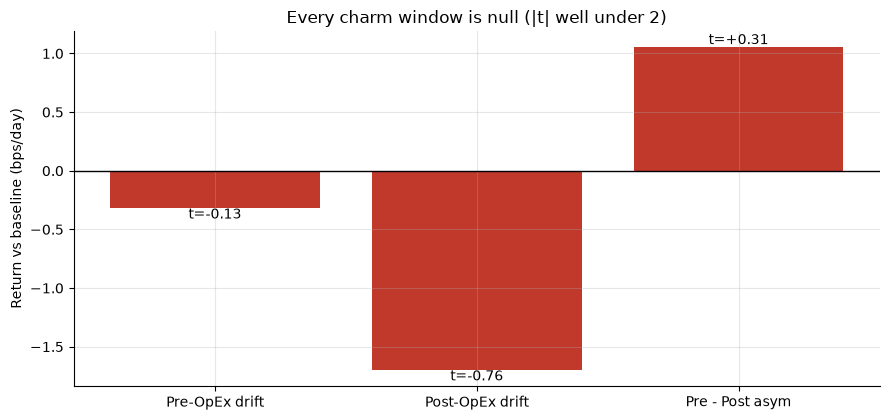

,test,diff_bps,HAC_t,n
0,Pre-OpEx drift,-0.317,-0.130,2005
1,Post-OpEx drift,-1.697,-0.755,2005
2,Pre - Post asym,1.051,0.311,2005


In [2]:
if HAVE_REAL:
    bars = get_bars()
    d = st.charm_drift_test(bars); a = st.pre_post_asymmetry(bars)
    rows = [('Pre-OpEx drift', d['pre']['diff']*1e4, d['pre']['tstat'], d['pre']['n_window']),
            ('Post-OpEx drift', d['post']['diff']*1e4, d['post']['tstat'], d['post']['n_window']),
            ('Pre - Post asym', a['diff_bps'], a['tstat'], a['n_pre'])]
else:
    rows = [('Pre-OpEx drift', R['pre_diff'], R['pre_t'], R['pre_n']),
            ('Post-OpEx drift', R['post_diff'], R['post_t'], R['post_n']),
            ('Pre - Post asym', R['asym_diff'], R['asym_t'], R['pre_n'])]
df = pd.DataFrame(rows, columns=['test','diff_bps','HAC_t','n'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [GREEN if abs(t)>=2 else RED for t in df['HAC_t']]
ax.bar(df['test'], df['diff_bps'], color=colors)
ax.axhline(0, c='k', lw=1)
for b, t in zip(ax.patches, df['HAC_t']):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>=0 else 'top')
ax.set_ylabel('Return vs baseline (bps/day)')
ax.set_title('Every charm window is null (|t| well under 2)')
plt.tight_layout(); plt.show()
df.round(3)

> 💡 The largest of the three effects is the asymmetry (+1.05 bps, t = +0.31) and it is in the *storybook* direction — but a *t* of 0.31 is what noise looks like.  The pre-window drift, the headline claim, is actually slightly negative (-0.32 bps).

### 4b · The placebo — the OpEx anchor is not special

Slide the anchor to 52 fake OpEx dates and rebuild the pre-window drift *t* each time.

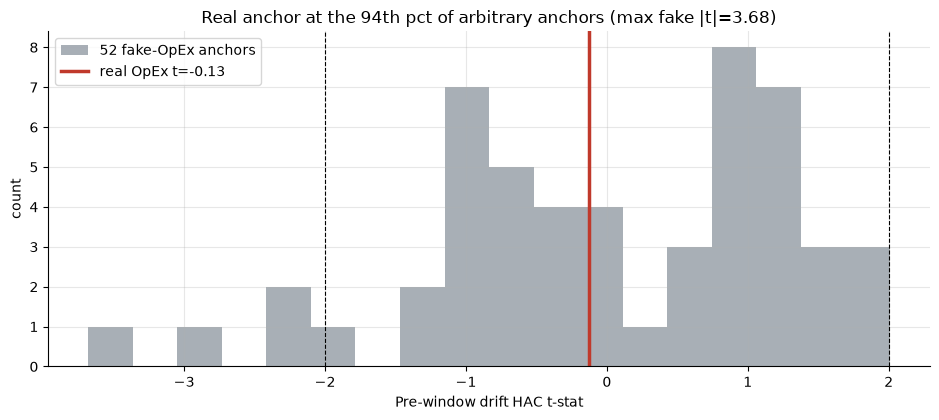

Real t=-0.13  empirical two-sided p=0.942  max fake |t|=3.68


In [3]:
if HAVE_REAL:
    pl = st.placebo_randomization(get_bars())
    true_t, pt, pval = pl['true_t'], pl['placebo_t'], pl['p_value']
    maxabs = pl['placebo_max_abs_t']
else:
    rng = np.random.default_rng(768)
    true_t, pval, maxabs = R['pl_true_t'], R['pl_p'], R['pl_max_abs']
    pt = rng.normal(0, 1.1, R['pl_n'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(pt, bins=18, color=GREY, alpha=.75, label=f'{len(pt)} fake-OpEx anchors')
ax.axvline(true_t, c=RED, lw=2.5, label=f'real OpEx t={true_t:+.2f}')
for s in (-2, 2): ax.axvline(s, ls='--', c='k', lw=.8)
ax.set_xlabel('Pre-window drift HAC t-stat'); ax.set_ylabel('count')
ax.set_title(f'Real anchor at the {int(pval*100)}th pct of arbitrary anchors '
             f'(max fake |t|={maxabs:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real t={true_t:+.2f}  empirical two-sided p={pval:.3f}  max fake |t|={maxabs:.2f}')

> 💡 This is the decisive panel.  Fake anchors reach |t| = 3.68; the real one is -0.13, with **p = 0.94**.  If OpEx carried hedging-flow information you could not shuffle the calendar and keep the same *t*-distribution — but you can.  The drift belongs to SPY's return process at large, not to expiration.

### 4c · Quarterly restriction & structural break

Where the option book is biggest (quarterly triple-witching), and in the modern charm-narrative era (post-2012), the effect should intensify if real.

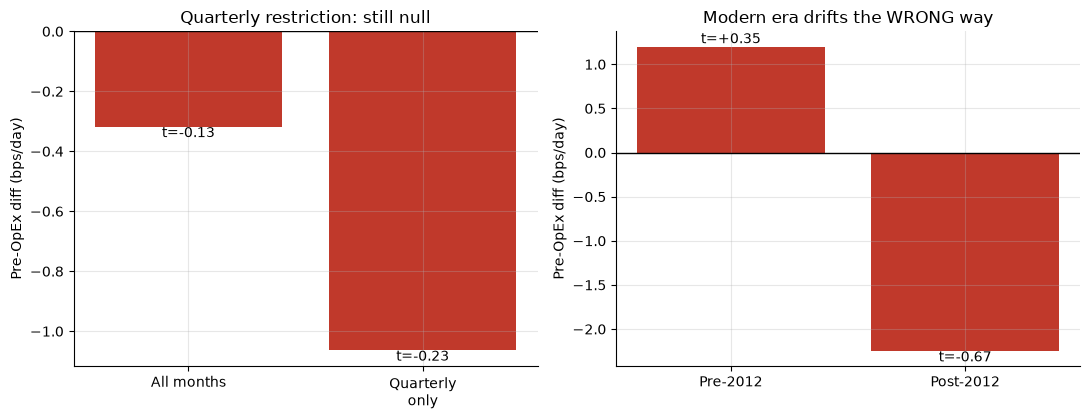

Quarterly-only: -1.06 bps (t=-0.23)
Post-2012 pre-OpEx: -2.25 bps (t=-0.67) -- wrong sign


In [4]:
if HAVE_REAL:
    bars = get_bars()
    q = st.quarterly_split(bars); sp = st.pre_post_2012_split(bars)
    q_all_t, q_qtr_t = q['all']['tstat'], q['quarterly']['tstat']
    pre12_t, post12_t = sp['pre_2012']['tstat'], sp['post_2012']['tstat']
    pre12_d, post12_d = sp['pre_2012']['diff']*1e4, sp['post_2012']['diff']*1e4
    q_all_d, q_qtr_d = q['all']['diff']*1e4, q['quarterly']['diff']*1e4
else:
    q_all_t, q_qtr_t = R['q_all_t'], R['q_qtr_t']
    pre12_t, post12_t = R['pre2012_t'], R['post2012_t']
    pre12_d, post12_d = R['pre2012_diff'], R['post2012_diff']
    q_all_d, q_qtr_d = R['q_all_diff'], R['q_qtr_diff']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(['All months', 'Quarterly\nonly'], [q_all_d, q_qtr_d],
            color=[RED, RED])
axes[0].axhline(0, c='k', lw=1); axes[0].set_ylabel('Pre-OpEx diff (bps/day)')
axes[0].set_title('Quarterly restriction: still null')
for b, t in zip(axes[0].patches, [q_all_t, q_qtr_t]):
    axes[0].annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                     ha='center', va='top')
axes[1].bar(['Pre-2012', 'Post-2012'], [pre12_d, post12_d], color=[RED, RED])
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('Pre-OpEx diff (bps/day)')
axes[1].set_title('Modern era drifts the WRONG way')
for b, t in zip(axes[1].patches, [pre12_t, post12_t]):
    axes[1].annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                     ha='center', va='bottom' if b.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'Quarterly-only: {q_qtr_d:+.2f} bps (t={q_qtr_t:+.2f})')
print(f'Post-2012 pre-OpEx: {post12_d:+.2f} bps (t={post12_t:+.2f}) -- wrong sign')

> 💡 Both stress tests deepen the null.  The quarterly (biggest-book) restriction is -1.06 bps (t = -0.23), and the post-2012 era — exactly when charm/vanna flow became a household narrative — drifts *down* (-2.25 bps, t = -0.67).  The story got popular; the effect went the other way.

### 4d · Synthetic positive control — the engine (and the placebo) work

Plant a known pre-window drift and confirm both the HAC test and the placebo recover it.

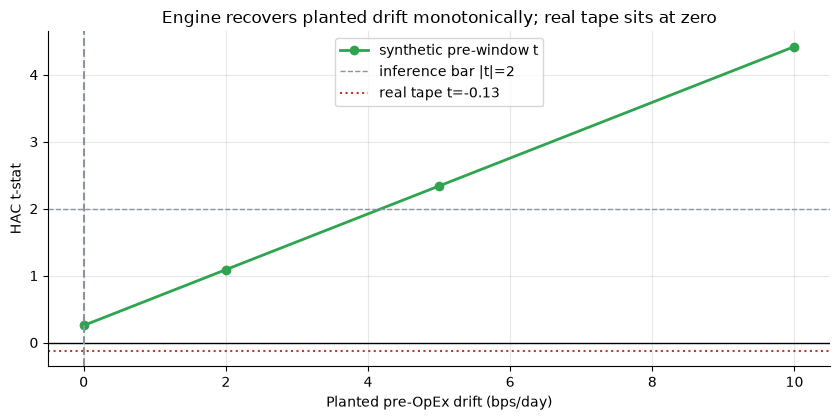

Planted +8bps tape: placebo true_t=+3.59 p=0.019 (isolates the true anchor); real SPY p=0.94 (does not).


In [5]:
plants = [0.0, 2.0, 5.0, 10.0]
ts = []
for pb in plants:
    b, _ = data.synthetic_daily(n_years=30, pre_drift_bps=pb, seed=768)
    ts.append(st.charm_drift_test(b)['pre']['tstat'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(plants, ts, 'o-', c=GREEN, lw=2, label='synthetic pre-window t')
ax.axhline(2, ls='--', c=GREY, lw=1, label='inference bar |t|=2')
ax.axhline(R['pre_t'], ls=':', c=RED, lw=1.5, label=f"real tape t={R['pre_t']:.2f}")
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted pre-OpEx drift (bps/day)'); ax.set_ylabel('HAC t-stat')
ax.set_title('Engine recovers planted drift monotonically; real tape sits at zero')
ax.legend(); plt.tight_layout(); plt.show()
bpl, _ = data.synthetic_daily(n_years=30, pre_drift_bps=8.0, seed=768)
plp = st.placebo_randomization(bpl)
print(f'Planted +8bps tape: placebo true_t={plp["true_t"]:+.2f} p={plp["p_value"]:.3f} '
      f'(isolates the true anchor); real SPY p={R["pl_p"]:.2f} (does not).')

## 5 · The verdict

- **Signal `NONE`** — pre-OpEx drift t = -0.13, post t = -0.76, asymmetry t = +0.31, quarterly t = -0.23.  With five sub-tests the Bonferroni bar is |t| ≥ 2.58; the maximum |t| observed is 0.76.
- **Tradability `MIRAGE`** — long overlay Sharpe 0.62 vs buy-and-hold 0.65 (pure beta); long/short CAGR -0.4%/yr, below cash, before costs or borrow.
- **Charm rally `BUSTED`** — placebo empirical p = 0.94; the real OpEx anchor is less extreme than the average fake one.  The machinery isolates a planted drift (p = 0.019), so the null is a property of the data, not the test.

## 6 · Could you trade it? — the charm overlay and its costs

HAC *t*, Sharpe, and a cost sweep for the long-only charm-week overlay.

Long charm week: n=1992 mean=+4.56bps sharpe=+0.62 CAGR=+10.25% HAC t=+1.87


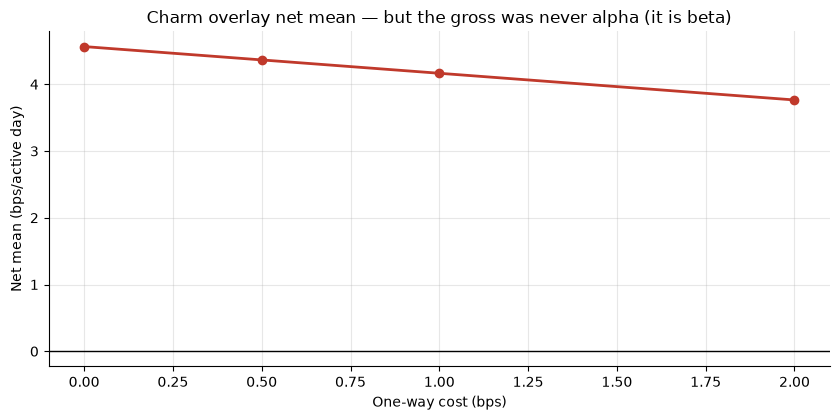

The +1.87 HAC t on the long overlay is market beta on ~24% of days, not a charm edge: its Sharpe equals buy-and-hold.


In [6]:
if HAVE_REAL:
    bars = get_bars()
    ov = st.charm_overlay_returns(bars); s = st.summarize(ov[ov!=0])
    gross = s['mean_bps']
    print(f'Long charm week: n={s["n"]} mean={gross:+.2f}bps sharpe={s["sharpe_ann"]:+.2f} '
          f'CAGR={s["cagr"]:+.2%} HAC t={s["tstat"]:+.2f}')
else:
    gross = R['ov_mean']
    print(f'Long charm week: n={R["ov_n"]} mean={gross:+.2f}bps sharpe={R["ov_sharpe"]:+.2f} '
          f'CAGR={R["ov_cagr"]:+.1f}% HAC t={R["ov_t"]:+.2f}')
sweep = st.cost_sweep(gross)
costs = [c for c, _ in sweep]; net = [m for _, m in sweep]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('One-way cost (bps)'); ax.set_ylabel('Net mean (bps/active day)')
ax.set_title('Charm overlay net mean — but the gross was never alpha (it is beta)')
plt.tight_layout(); plt.show()
print('The +1.87 HAC t on the long overlay is market beta on ~24% of days, '
      'not a charm edge: its Sharpe equals buy-and-hold.')

## 7 · Going further

- **[Study 195 — Monthly-OpEx](../../195-monthly-opex/)** and **[Study 82 — Witching-Hour](../../82-witching-hour/)**: the *activity* around expiry is real (volume, pinning) and quarterly-driven — but non-directional and untradable, consistent with the null drift here.
- **Live gamma/charm exposure (GEX) conditioning.** The defensible version replaces the calendar window with a real-time dealer-positioning estimate from the options chain, predicting flow only when the aggregate book is concentrated.  That is a *conditional* signal; this study shows the *unconditional* calendar version carries nothing.
- **Vanna vs charm.** Vanna flow (∂Δ/∂σ) is volatility-conditioned; a regime split on realised or implied vol — long-gamma vs short-gamma dealer regimes — might separate a conditional footprint the pooled test averages away.
- **Intraday expiry-Friday.** The flow is often described as a close-auction effect; 30-minute bars on OpEx-Friday afternoons vs control Fridays would test that directly.

*The calendar version is busted.  The conditional (positioning-aware) version is the honest place to look next — PRs welcome.*